In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

data = pd.read_csv("resume_dataset_with_salary.csv")


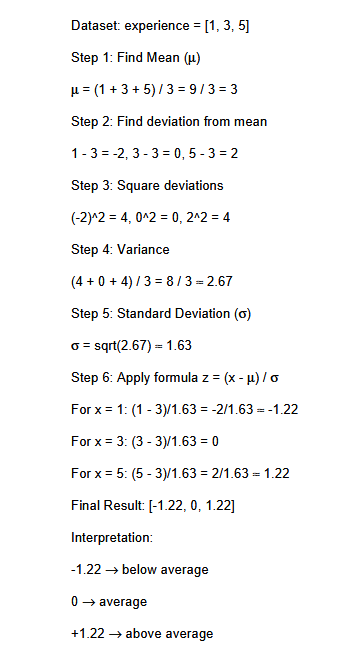

In [4]:
# used to display the image
# Understanding the concept of the StandardScaler
# Standardization (Z-Score) Full Step-by-Step
from IPython.display import Image, display

display(Image("screenshot.png"))

In [5]:
# converting the education into numerical
data["education"] = data["education"].astype("string").str.strip().str.lower()
edu_map={
    "PhD":1,
    "Master":2,
    "Bachelor":3
}

data["education"] = data["education"].map(edu_map)
data["education"] = data["education"].fillna(0).astype(int)

In [6]:
X = data[["experience","education"]]

# storing the columns before the standarization
feature_names = X.columns.tolist()

Y = data["salary"]


# use of StandardScaler -> It removes scale differences and centers data

scaler= StandardScaler()

scaler.fit(X)
standardized_data = scaler.transform(X)
X = standardized_data

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)


model = LinearRegression()
model.fit(X_train,Y_train)

y_predictions = model.predict(X_train)

'''using the r2_score because the accuracy_score is not working on this dataset and will return zero
example -
          y_true = [0, 1, 1, 0, 1]
          y_pred = [0, 1, 0, 0, 1]
          accuracy = 4 / 5 = 0.8

'''

# predicting the accuracy of the trained data
training_data_accuracy = r2_score(Y_train,y_predictions)
print("R-squared on training data is : ",training_data_accuracy*100)

# predicting the data on the test data
y_prediction = model.predict(X_test)
test_data_accuracy = r2_score(Y_test,y_prediction)
print("R-squared on the testing data is: ", test_data_accuracy*100)


R-squared on training data is :  85.11506847899332
R-squared on the testing data is:  83.66256945746996


In [7]:
# saving the file
import pickle
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(feature_names, open("features.pkl", "wb")) # it will make sure all the columns are saved in the same order

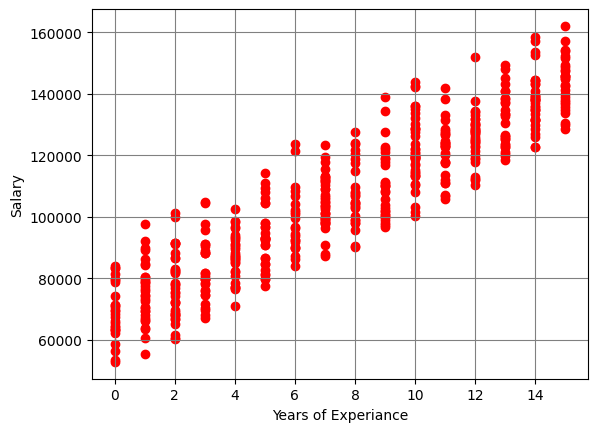

In [8]:
experience = data["experience"]
salary = data["salary"]
plt.scatter(experience,salary,color="red")
# plt.plot(X_train,y_predictions,color="blue")
plt.xlabel("Years of Experiance")
plt.ylabel("Salary")
plt.grid(color="gray")
plt.show()

# the graph shows with the increasing no of years the salary increases

In [9]:
# Making the predictive System
model = pickle.load(open("model.pkl","rb"))
scaler = pickle.load(open("scaler.pkl","rb"))
features = pickle.load(open("features.pkl","rb"))

experience = int(input("Enter the years of Expericance: "))

education = input("Enter education (Bachelor/Master/PhD): ").strip().lower()

edu_map = {"bachelor":1 ,"master":2,"phd":3}

updated_value = edu_map.get(education,0) # get works on the one input and the map works on the entire column

'''
understanding the 1d and 2d

pd.DataFrame([experience, education]) -> create the problem  -> 1D

   0
0  5
1  2

pd.DataFrame([[experience, education]])  solves the problem -> 2D

   0  1
0  5  2
'''
input_data = pd.DataFrame([[experience, updated_value]], columns=features)

# scaling the data
input_scaled = scaler.transform(input_data)


# predicting the value
prediction = model.predict(input_scaled)


print(f"\033[32mThe Predicted Salary is: {prediction[0]:.0f}\033[0m")

The Predicted Salary is: 93607
